In [1]:
!pip install yfinance
!pip install scikit-optimize

Defaulting to user installation because normal site-packages is not writeable
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 1.7/1.7 MB 10.7 MB/s eta 0:00:00
   ---------------------------------------- 9.8/9.8 MB 24.7 MB/s eta 0:00:00
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 8.2/8.2 MB 23.3 MB/s eta 0:00:00
   ---------------------------------------- 36.5/36.5 MB 25.5 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns # added for plotting
from scipy.linalg import solve
import yfinance as yf
import numba

In [3]:
# iid data
np.random.seed(42)
X_all = np.random.rand(10000, 1) * 10  # Generate 1000 one-dimensional input data points
y_all = np.sin(X_all[:, 0]) + np.random.randn(10000) * 0.1  # Noisy target values

In [4]:
# Shift data
np.random.seed(42)
X_all = np.random.rand(10000, 1) * 10  # Generate 1000 one-dimensional input data points
y_first = np.sin(X_all[:5000, 0]) + np.random.randn(5000) * 0.1
y_last = np.sin(X_all[5000:, 0])+ np.random.randn(5000) * 0.2
y_all = np.concatenate([y_first, y_last])

In [5]:
# real world data

ticker = 'AAPL'
data = yf.download(ticker, start='2016-01-01', end='2021-01-01')
X_all = data[['Open','High','Low']].values
y_all = data['Close'].values

C:\Users\Maxim\AppData\Local\Temp\ipykernel_11140\2898502743.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2016-01-01', end='2021-01-01')
[*********************100%***********************]  1 of 1 completed


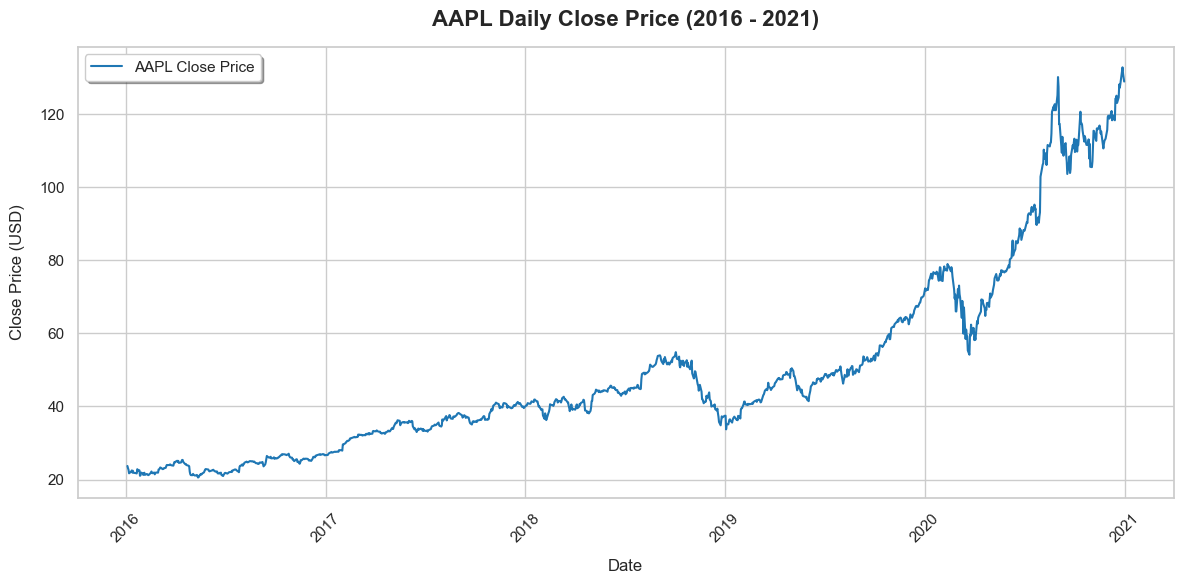

In [7]:
sns.set_theme(style="whitegrid")

# plot
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], color='#1f77b4', linewidth=1.5, label='AAPL Close Price')

plt.title(f"{ticker} Daily Close Price (2016 - 2021)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Close Price (USD)", fontsize=12, labelpad=10)

plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('aapl_stock_plot.png', dpi=300)
plt.show()